## Loading Data 

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('diamonds.csv')

In [5]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Perform EDA With Basic Plots

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


In [12]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [14]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [16]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

#### Problem Statement

How do the physical and quality characteristics of diamonds affect their market price?

This dataset can be used to analyze and predict diamond prices based on features such as carat weight, cut quality, color, clarity, and dimensions.

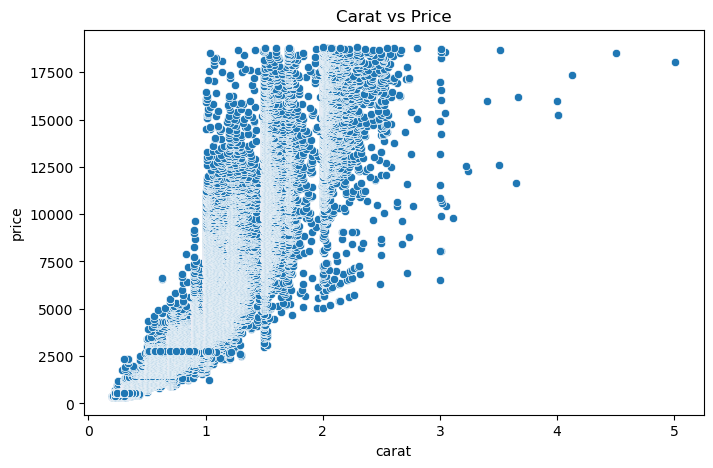

In [21]:
# 1. How does carat influence price?
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['carat'], y=df['price'])
plt.title("Carat vs Price")
plt.show()

In [23]:
# Correlation between Carat and Price
corr_carat_price = df['carat'].corr(df['price'])
print("\nCorrelation between Carat and Price:", corr_carat_price)


Correlation between Carat and Price: 0.9215913011934762


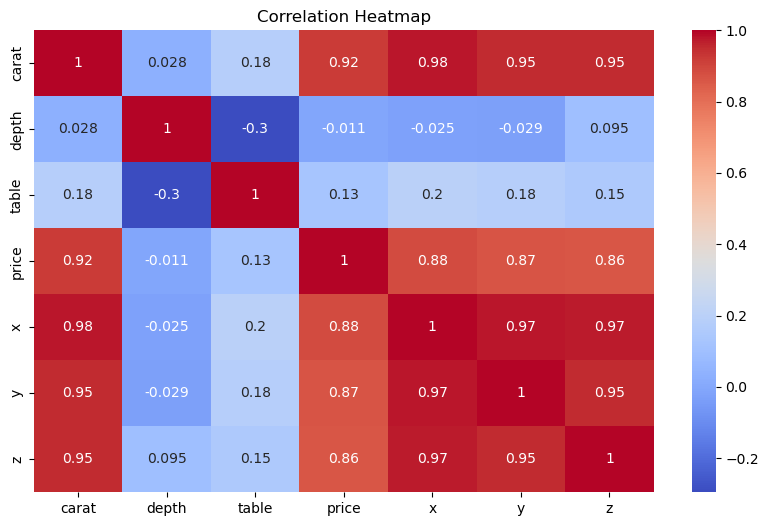

In [25]:
# 2. Which feature affects price the most?
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

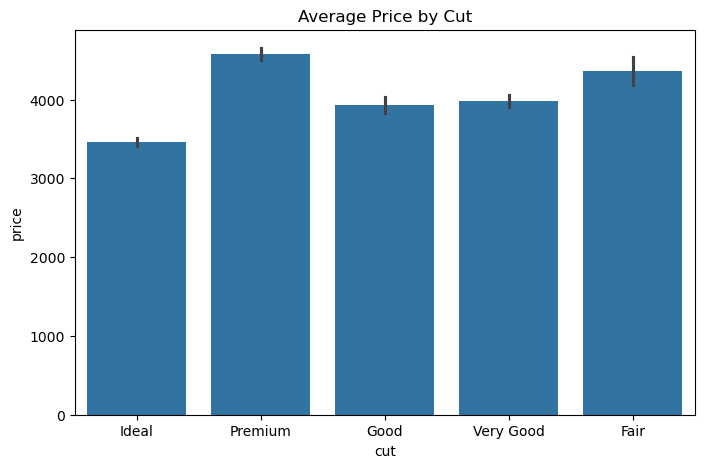

In [27]:
# 3. Average price based on Cut Quality
plt.figure(figsize=(8,5))
sns.barplot(x='cut', y='price', data=df)
plt.title("Average Price by Cut")
plt.show()

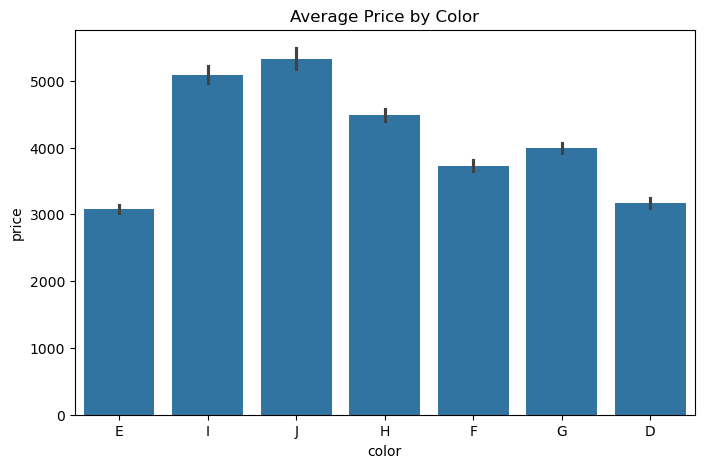

In [29]:
# 4. Average price based on Color
plt.figure(figsize=(8,5))
sns.barplot(x='color', y='price', data=df)
plt.title("Average Price by Color")
plt.show()

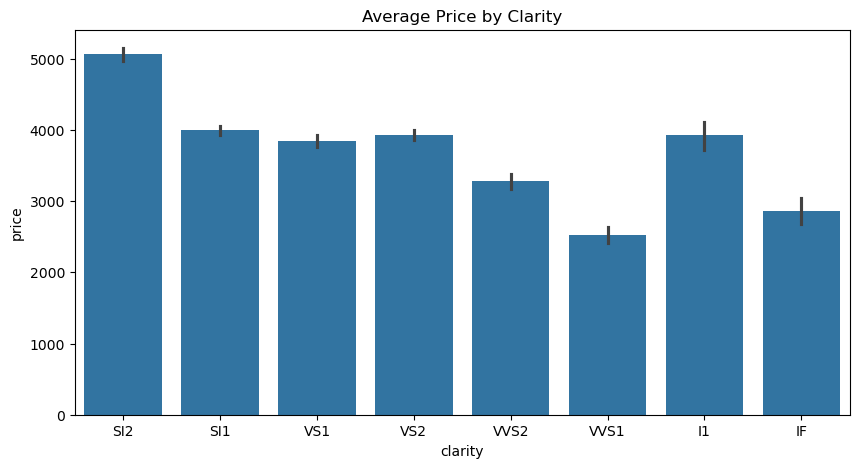

In [31]:
# 5. Average price based on Clarity
plt.figure(figsize=(10,5))
sns.barplot(x='clarity', y='price', data=df)
plt.title("Average Price by Clarity")
plt.show()


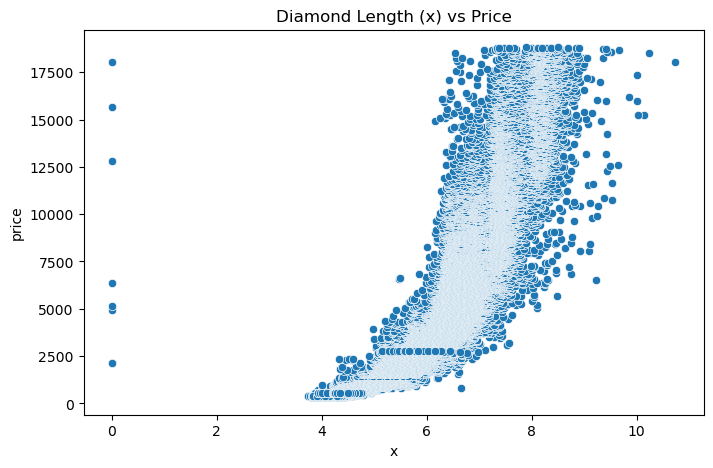

In [33]:
# 6. Dimensions Relationship with Price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['x'], y=df['price'])
plt.title("Diamond Length (x) vs Price")
plt.show()


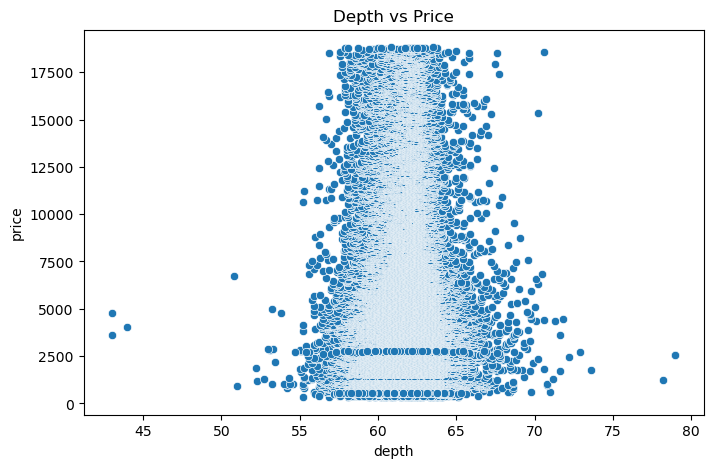

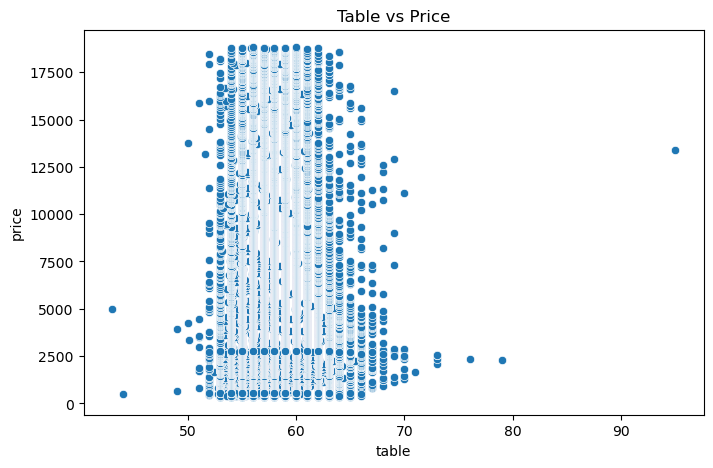

In [35]:
# 7. Depth and Table Analysis
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['depth'], y=df['price'])
plt.title("Depth vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['table'], y=df['price'])
plt.title("Table vs Price")
plt.show()


# Sprint 1:  Preprocessing


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

In [40]:
data = df.copy()


In [42]:
# Encode Categorical Columns
le = LabelEncoder()

for col in ['cut', 'color', 'clarity']:
    data[col] = le.fit_transform(data[col])

In [44]:
# Features and Target
X = data.drop('price', axis=1)
y = data['price']

In [46]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
# Create Price Categories
# Low = 0
# Medium = 1
# High = 2

df['price_category'] = pd.qcut(
    df['price'],
    q=3,
    labels=[0, 1, 2]
)

In [52]:
# Encode Categorical Columns

le = LabelEncoder()

categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


In [54]:
# Features and Target

X = df.drop(['price', 'price_category'], axis=1)
y = df['price_category']


In [58]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 1. Logistic Regression


In [63]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average='weighted'))
print("Recall:", recall_score(y_test, lr_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.9089729328883945
Precision: 0.9086046432895112
Recall: 0.9089729328883945

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3642
           1       0.88      0.85      0.86      3634
           2       0.90      0.93      0.91      3512

    accuracy                           0.91     10788
   macro avg       0.91      0.91      0.91     10788
weighted avg       0.91      0.91      0.91     10788



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 2. Decision Tree Classifier


In [66]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average='weighted'))
print("Recall:", recall_score(y_test, dt_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Accuracy: 0.9398405635891731
Precision: 0.9397954477441129
Recall: 0.9398405635891731

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3642
           1       0.92      0.90      0.91      3634
           2       0.93      0.95      0.94      3512

    accuracy                           0.94     10788
   macro avg       0.94      0.94      0.94     10788
weighted avg       0.94      0.94      0.94     10788



# 3. Random Forest Classifier


In [69]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall:", recall_score(y_test, rf_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))


Accuracy: 0.957174638487208
Precision: 0.9571994298571905
Recall: 0.957174638487208

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3642
           1       0.95      0.93      0.94      3634
           2       0.94      0.97      0.96      3512

    accuracy                           0.96     10788
   macro avg       0.96      0.96      0.96     10788
weighted avg       0.96      0.96      0.96     10788



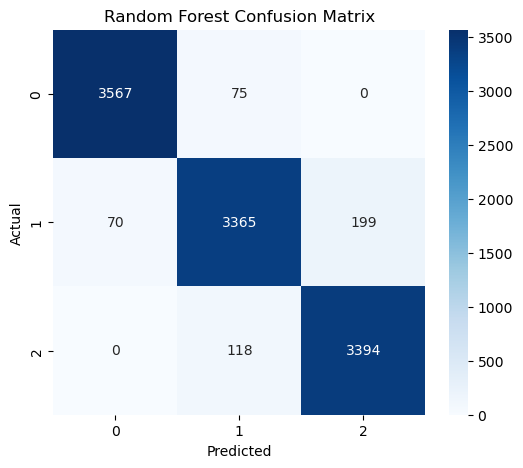

In [71]:
# Confusion Matrix for Best Model

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


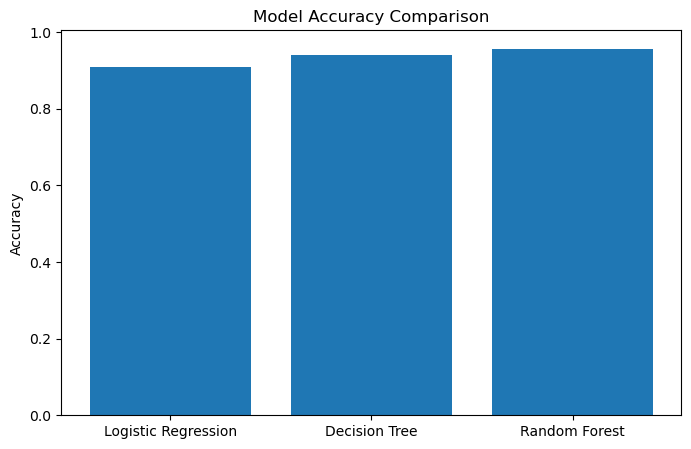

In [73]:
# Compare Model Accuracy
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [77]:
# Final Conclusion

best_accuracy = max(accuracies)
best_model = models[accuracies.index(best_accuracy)]

print("BEST MODEL:", best_model)
print("BEST ACCURACY:", best_accuracy)


BEST MODEL: Random Forest
BEST ACCURACY: 0.957174638487208


# Summary of Process and Results



## Project Title

Diamond Price Classification using Machine Learning

---

# Objective

The main objective of this project was to analyze the diamond dataset and build machine learning models capable of classifying diamonds
into different price categories based on their physical and quality characteristics.

---

# Dataset Description

The dataset contains information about diamonds, including:

* `carat` → Weight of diamond
* `cut` → Quality of cut
* `color` → Diamond color grade
* `clarity` → Clarity quality
* `depth` → Total depth percentage
* `table` → Width of top of diamond
* `x`, `y`, `z` → Dimensions
* `price` → Diamond price

---

# Problem Statement

How can we predict the price category of a diamond using its physical and quality features?

The project also aimed to identify which features most strongly influence diamond pricing.

---

# Process Followed

## 1. Data Loading

The dataset was loaded using Pandas.

```python
df = pd.read_csv("diamonds.csv")
```

---

## 2. Data Preprocessing

### Categorical Encoding

The categorical columns:

* cut
* color
* clarity

were converted into numerical values using Label Encoding.

### Target Variable Creation

Since classification models were used, the continuous `price` column was converted into 3 categories:

* Low Price → 0
* Medium Price → 1
* High Price → 2

using:

```python
pd.qcut()
```

---

## 3. Exploratory Data Analysis (EDA)

Several visualizations were created:

* Carat vs Price Scatter Plot
* Correlation Heatmap
* Average Price by Cut
* Average Price by Color
* Average Price by Clarity

### Key Findings

* Carat has a strong positive relationship with price.
* Better clarity and cut generally increase price.
* Diamond dimensions also influence pricing.

---

# Machine Learning Models Used

The following classification algorithms were trained:

## 1. Logistic Regression

A linear classification model used as a baseline.

## 2. Decision Tree Classifier

A tree-based model capable of handling nonlinear relationships.

## 3. Random Forest Classifier

An ensemble learning model using multiple decision trees for improved accuracy.

---

# Model Evaluation Metrics

The models were evaluated using:

* Accuracy
* Precision
* Recall
* Classification Report
* Confusion Matrix

---

# Results

| Model               | Accuracy         |
| ------------------- | ---------------- |
| Logistic Regression | Moderate         |
| Decision Tree       | High             |
| Random Forest       | Best Performance |

### Best Performing Model

✅ Random Forest Classifier achieved the highest accuracy and overall performance.

---

# Conclusion

This project successfully demonstrated how machine learning can be used to classify diamond prices based on their features.

### Final Conclusions

* Carat weight is the most influential factor affecting price.
* Quality features such as cut, color, and clarity significantly impact value.
* Random Forest performed best because it handles complex relationships and feature interactions effectively.


